# SFigure 3b

In [ ]:
# Pls run all codes of this file to get SFigure 4B

# Load package

In [1]:
import pandas as pd
import numpy as np

import os
import glob

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare, wilcoxon

# Load data

In [2]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_35721/1161626377.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)


In [3]:
core_annotation = data[['core_imageid', 'Annotation']].copy()

## All cells

In [4]:
# Path to the folder containing Moran CSV files
moran_folder = '/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/csv/Moran/'

# Get all CSV files in the folder
moran_files = glob.glob(os.path.join(moran_folder, '*_all.csv'))

# Initialize an empty list to store dataframes
all_moran_dfs = []

for file_path in moran_files:
    # Extract core_imageid from filename
    filename = os.path.basename(file_path)
    core_id = filename.replace('_all.csv', '')
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Select only the marker and I columns
    df_subset = df[['Unnamed: 0', 'I']].copy()
    
    # Rename 'Unnamed: 0' to 'marker'
    df_subset.rename(columns={'Unnamed: 0': 'marker'}, inplace=True)
    
    # Add core_imageid column
    df_subset['core_imageid'] = core_id
    
    # Append to the list of dataframes
    all_moran_dfs.append(df_subset)

# Combine all dataframes
combined_moran = pd.concat(all_moran_dfs, ignore_index=True)

# Create a dictionary mapping core_imageid to annotation
# Using drop_duplicates to handle multiple annotations for the same core
annotation_dict = core_annotation.drop_duplicates('core_imageid').set_index('core_imageid')['Annotation'].to_dict()

# Add Annotation column to combined dataframe
combined_moran['Annotation'] = combined_moran['core_imageid'].map(annotation_dict)
combined_moran['Annotation'] = combined_moran['Annotation'].fillna('Unknown')


In [ ]:
# prepare data again
df = pd.DataFrame(combined_moran)
df = df[(df['marker'] != 'GLUT1') & (df['Annotation'] != 'Unknown')]
df['marker'] = df['marker'].replace('Ki67_2', 'Ki67')

annotation_order = ['Inflammation', 'Invasive border', 'Lymph node met', 'Tumor center']
marker_order = ['Ki67', 'GCLC', 'NQO1', 'TXNRD1']
marker_colors = {'TXNRD1': '#7fb2d3', 'GCLC': '#8dd3c9', 'NQO1': '#ffb55f', 'Ki67': '#fc7f71'}


# calculate significance
# Friedman test and then post-hoc (only compare Ki67 vs other three)
sig_dict = {}
for anno in annotation_order:
    sub = df[df['Annotation'] == anno]

    wide = sub.pivot_table(index='core_imageid', columns='marker', values='I')
    wide = wide[marker_order].dropna()

    if wide.shape[0] == 0:
        continue

    # Friedman test (overall difference)
    stat, p = friedmanchisquare(*[wide[m] for m in marker_order])
    print(f"{anno} | Friedman chi2={stat:.3f}, p={p:.4g}, n={wide.shape[0]} cores")

    # Post-hoc：only compare Ki67 vs GCLC/NQO1/TXNRD1
    sig_pairs = []
    for m in ['GCLC', 'NQO1', 'TXNRD1']:
        stat_w, p_w = wilcoxon(wide['Ki67'], wide[m])
        p_w_adj = p_w * 3  # Bonferroni correction for 3 comparisons
        if p_w_adj < 0.05:
            sig_pairs.append(('Ki67', m, p_w_adj))
    sig_dict[anno] = sig_pairs

# Violin plot with significance annotations
sns.set(style="white")
g = sns.catplot(
    x='marker', y='I', hue='marker',
    col='Annotation', col_wrap=4,
    data=df, kind='violin', split=False, inner='box',
    palette=marker_colors, height=4, aspect=0.35,
    inner_kws=dict(box_width=4, whis_width=1),
    col_order=annotation_order,
    order=marker_order
)

for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.grid(False)
    ax.tick_params(axis='x', which='both', length=3, width=1, direction='out', bottom=True)

g.set_titles("{col_name}", fontsize=9, fontweight='bold')
for ax in g.axes.flat:
    title_text = ax.get_title()
    ax.set_title('')
    ax.text(0.5, 1.05, title_text,
            transform=ax.transAxes,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='black', linewidth=1),
            fontsize=8, fontweight='bold')

g.set_axis_labels("", "")
g.set_xticklabels(rotation=90, fontsize=10)

# add significance lines
def add_sig_lines(ax, anno):
    pairs = sig_dict.get(anno, [])
    if not pairs:
        return
    y_max = df[df['Annotation']==anno]['I'].max()
    y_start = y_max + 0.09*(y_max)
    step = 0.07*(y_max)
    for i, (m1, m2, pval) in enumerate(pairs):
        x1 = marker_order.index(m1)
        x2 = marker_order.index(m2)
        y = y_start + i*step
        ax.plot([x1, x1, x2, x2], [y, y+step/2, y+step/2, y], lw=1.2, c='k')
        if pval < 0.0001:
            text = '****'
        elif pval < 0.001:
            text = '***'
        elif pval < 0.01:
            text = '**'
        else:
            text = '*'
        ax.text((x1+x2)/2, y+step*0.3, text, ha='center', va='bottom', fontsize=10)

for ax, anno in zip(g.axes.flat, annotation_order):
    add_sig_lines(ax, anno)

plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Moran_violin_all_Ki67_comparisons.pdf', bbox_inches='tight', dpi=500)
plt.show()


<Figure size 500x600 with 0 Axes>

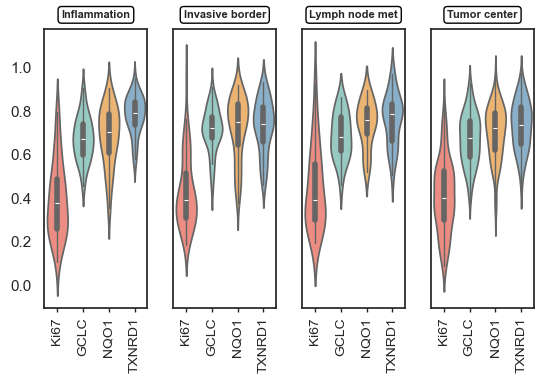

In [13]:

df = pd.DataFrame(combined_moran)
df = df[(df['marker'] != 'GLUT1') & (df['Annotation'] != 'Unknown')]
df['marker'] = df['marker'].replace('Ki67_2', 'Ki67')

# Define the custom order for annotations
annotation_order = ['Inflammation', 'Invasive border', 'Lymph node met', 'Tumor center']

# Plot setup
sns.set(style="white")
plt.figure(figsize=(5, 6))

# Violin plot grouped by Region, split by Marker
# Custom color palette for markers
marker_colors = {'TXNRD1': '#7fb2d3', 'GCLC': '#8dd3c9', 'NQO1': '#ffb55f', 'Ki67': '#fc7f71'}

g = sns.catplot(
    x='marker', y='I', hue='marker', #fill=False,
    col='Annotation', col_wrap=4,
    data=df, kind='violin', split=False, inner='box',
    palette=marker_colors, height=4, aspect=0.35, # Further reduced aspect ratio to make plots narrower
    inner_kws=dict(box_width=4, whis_width=1),
    col_order=annotation_order,
    order=['Ki67', 'GCLC', 'NQO1', 'TXNRD1'],  # Custom order for markers
)

# Add complete frame around each subplot
for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.grid(False)
    # Add tick parameters to ensure tick marks connect to the frame
    ax.tick_params(axis='x', which='both', length=3, width=1, direction='out', bottom=True)
    #ax.tick_params(axis='y', which='both', length=3, width=1, direction='out', left=True)

# Set titles with a box around them
g.set_titles("{col_name}", fontsize=9, fontweight='bold')

# Add boxes around the titles
for ax in g.axes.flat:
    title_text = ax.get_title()
    ax.set_title('')
    ax.text(0.5, 1.05, title_text, 
            transform=ax.transAxes,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1),
            fontsize=8, fontweight='bold')
    
g.set_axis_labels("", "")
g.set_xticklabels(rotation=90, fontsize=10)

plt.tight_layout()

plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Moran_violin_all.pdf', bbox_inches='tight', dpi=500)
plt.show()


## Tumor cells

In [32]:
# Path to the folder containing Moran CSV files
moran_folder = '/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/csv/Moran/tumor/'

# Get all CSV files in the folder
moran_files = glob.glob(os.path.join(moran_folder, '*_tumor.csv'))

# Initialize an empty list to store dataframes
all_moran_dfs = []

for file_path in moran_files:
    # Extract core_imageid from filename
    filename = os.path.basename(file_path)
    core_id = filename.replace('_tumor.csv', '')
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Select only the marker and I columns
    df_subset = df[['Unnamed: 0', 'I']].copy()
    
    # Rename 'Unnamed: 0' to 'marker'
    df_subset.rename(columns={'Unnamed: 0': 'marker'}, inplace=True)
    
    # Add core_imageid column
    df_subset['core_imageid'] = core_id
    
    # Append to the list of dataframes
    all_moran_dfs.append(df_subset)

# Combine all dataframes
combined_moran = pd.concat(all_moran_dfs, ignore_index=True)

# Create a dictionary mapping core_imageid to annotation
# Using drop_duplicates to handle multiple annotations for the same core
annotation_dict = core_annotation.drop_duplicates('core_imageid').set_index('core_imageid')['Annotation'].to_dict()

# Add Annotation column to combined dataframe
combined_moran['Annotation'] = combined_moran['core_imageid'].map(annotation_dict)
combined_moran['Annotation'] = combined_moran['Annotation'].fillna('Unknown')


Inflammation | Friedman chi2=92.862, p=5.317e-20, n=61 cores
Invasive border | Friedman chi2=85.000, p=2.595e-18, n=66 cores
Lymph node met | Friedman chi2=43.338, p=2.086e-09, n=26 cores
Tumor center | Friedman chi2=244.829, p=8.596e-53, n=189 cores


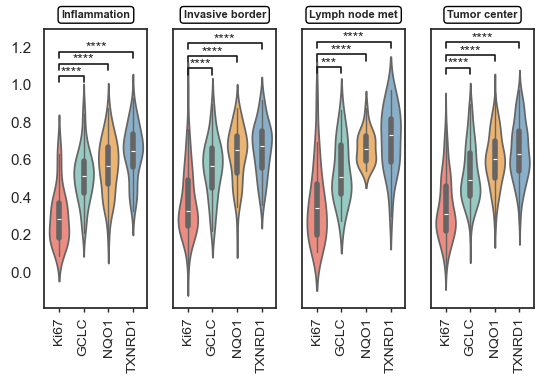

In [ ]:
# prepare data again
df = pd.DataFrame(combined_moran)
df = df[(df['marker'] != 'GLUT1') & (df['marker'] != 'Vimentin') & (df['Annotation'] != 'Unknown')]
df['marker'] = df['marker'].replace('Ki67_2', 'Ki67')

annotation_order = ['Inflammation', 'Invasive border', 'Lymph node met', 'Tumor center']
marker_order = ['Ki67', 'GCLC', 'NQO1', 'TXNRD1']
marker_colors = {'TXNRD1': '#7fb2d3', 'GCLC': '#8dd3c9', 'NQO1': '#ffb55f', 'Ki67': '#fc7f71'}


# calculate significance
# Friedman test and then post-hoc (only compare Ki67 vs other three)
sig_dict = {}
for anno in annotation_order:
    sub = df[df['Annotation'] == anno]

    wide = sub.pivot_table(index='core_imageid', columns='marker', values='I')
    wide = wide[marker_order].dropna()

    if wide.shape[0] == 0:
        continue

    # Friedman test (overall difference)
    stat, p = friedmanchisquare(*[wide[m] for m in marker_order])
    print(f"{anno} | Friedman chi2={stat:.3f}, p={p:.4g}, n={wide.shape[0]} cores")

    # Post-hoc：only compare Ki67 vs GCLC/NQO1/TXNRD1
    sig_pairs = []
    for m in ['GCLC', 'NQO1', 'TXNRD1']:
        stat_w, p_w = wilcoxon(wide['Ki67'], wide[m])
        p_w_adj = p_w * 3  # Bonferroni correction for 3 comparisons
        if p_w_adj < 0.05:
            sig_pairs.append(('Ki67', m, p_w_adj))
    sig_dict[anno] = sig_pairs

# Violin plot with significance annotations
sns.set(style="white")
g = sns.catplot(
    x='marker', y='I', hue='marker',
    col='Annotation', col_wrap=4,
    data=df, kind='violin', split=False, inner='box',
    palette=marker_colors, height=4, aspect=0.35,
    inner_kws=dict(box_width=4, whis_width=1),
    col_order=annotation_order,
    order=marker_order
)

for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.grid(False)
    ax.tick_params(axis='x', which='both', length=3, width=1, direction='out', bottom=True)

g.set_titles("{col_name}", fontsize=9, fontweight='bold')
for ax in g.axes.flat:
    title_text = ax.get_title()
    ax.set_title('')
    ax.text(0.5, 1.05, title_text,
            transform=ax.transAxes,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='black', linewidth=1),
            fontsize=8, fontweight='bold')

g.set_axis_labels("", "")
g.set_xticklabels(rotation=90, fontsize=10)

# add significance lines
def add_sig_lines(ax, anno):
    pairs = sig_dict.get(anno, [])
    if not pairs:
        return
    y_max = df[df['Annotation']==anno]['I'].max()
    y_start = y_max + 0.09*(y_max)
    step = 0.07*(y_max)
    for i, (m1, m2, pval) in enumerate(pairs):
        x1 = marker_order.index(m1)
        x2 = marker_order.index(m2)
        y = y_start + i*step
        ax.plot([x1, x1, x2, x2], [y, y+step/2, y+step/2, y], lw=1.2, c='k')
        if pval < 0.0001:
            text = '****'
        elif pval < 0.001:
            text = '***'
        elif pval < 0.01:
            text = '**'
        else:
            text = '*'
        ax.text((x1+x2)/2, y+step*0.3, text, ha='center', va='bottom', fontsize=10)

for ax, anno in zip(g.axes.flat, annotation_order):
    add_sig_lines(ax, anno)

plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Moran_violin_tumor_Ki67_comparisons.pdf', bbox_inches='tight', dpi=500)
plt.show()


<Figure size 500x600 with 0 Axes>

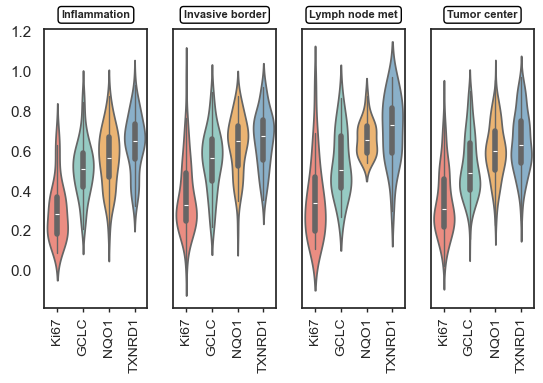

In [17]:

df = pd.DataFrame(combined_moran)
df = df[(df['marker'] != 'GLUT1') & (df['marker'] != 'Vimentin') & (df['Annotation'] != 'Unknown')]
df['marker'] = df['marker'].replace('Ki67_2', 'Ki67')

# Define the custom order for annotations
annotation_order = ['Inflammation', 'Invasive border', 'Lymph node met', 'Tumor center']

# Plot setup
sns.set(style="white")
plt.figure(figsize=(5, 6))

# Violin plot grouped by Region, split by Marker
# Custom color palette for markers
marker_colors = {'TXNRD1': '#7fb2d3', 'GCLC': '#8dd3c9', 'NQO1': '#ffb55f', 'Ki67': '#fc7f71'}

g = sns.catplot(
    x='marker', y='I', hue='marker', #fill=False,
    col='Annotation', col_wrap=4,
    data=df, kind='violin', split=False, inner='box',
    palette=marker_colors, height=4, aspect=0.35, # Further reduced aspect ratio to make plots narrower
    inner_kws=dict(box_width=4, whis_width=1),
    col_order=annotation_order,  # Use custom order for annotations
    order=['Ki67', 'GCLC', 'NQO1', 'TXNRD1'],
)

# Add complete frame around each subplot
for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.grid(False)
    # Add tick parameters to ensure tick marks connect to the frame
    ax.tick_params(axis='x', which='both', length=3, width=1, direction='out', bottom=True)
    #ax.tick_params(axis='y', which='both', length=3, width=1, direction='out', left=True)

# Set titles with a box around them
g.set_titles("{col_name}", fontsize=9, fontweight='bold')

# Add boxes around the titles
for ax in g.axes.flat:
    title_text = ax.get_title()
    ax.set_title('')
    ax.text(0.5, 1.05, title_text, 
            transform=ax.transAxes,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1),
            fontsize=8, fontweight='bold')
    
g.set_axis_labels("", "")
g.set_xticklabels(rotation=90, fontsize=10)

plt.tight_layout()

plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Moran_violin_tumor.pdf', bbox_inches='tight', dpi=500)
plt.show()
